# 📊 Sales Data Analysis - Exploratory Data Analysis

## 📚 Notebook Structure

1. Business Context
2. Data Loading
3. Initial Exploration
4. Data Quality Assessment
5. Data Cleaning
6. Feature Engineering
7. KPI Analysis
8. Time Series Analysis
9. Final Conclusions
10. Export Clean Dataset

## 🏢 1. Business Context

This analysis simulates a retail company aiming to improve sales performance and profitability.

## 🎯 Business Questions
- Which products drive the most revenue and profit?
- What is the impact of returns on business performance?
- Are there data quality issues affecting decision-making?

## 🎯 Objective
Analyze sales performance and data quality to identify key issues and insights.

## 📁 Dataset
Sales dataset containing transactions, products, customers, and financial metrics.

## 🧠 Approach
- Data exploration
- Data quality assessment
- Initial insights


In [ ]:
import os

In [126]:
import pandas as pd
import numpy as np

In [195]:
import matplotlib.pyplot as plt

In [140]:
from IPython.display import Markdown

## 💾 2. Data Loading

In [127]:
os.getcwd()

'/Users/dlf/Documents/PROJECT_BI_SALES_ANALYSIS/notebooks'

In [128]:
os.listdir('../data')

['Sales_Dataset_2024 (1).xlsx', 'sales_clean.csv', '.ipynb_checkpoints']

In [129]:
df = pd.read_excel('../data/Sales_Dataset_2024 (1).xlsx')

In [130]:
df.head() #Show columns

,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
0,2024-04-12,North,Smartwatch,Hannah,15.0,1224.0,Accessories,18360.0,16451.634258,1908.365742
1,2024-12-14,North,Monitor,Eva,5.0,1321.0,Office,6605.0,4457.351727,2147.648273
2,2024-09-27,North,Mobile,Bob,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874
3,2024-04-16,West,Monitor,Charlie,18.0,325.0,Office,5850.0,4320.807092,1529.192908
4,2024-03-12,West,Headphones,Eva,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334


## 🔍 3. Initial Exploration

In [131]:
df.shape #Dimension of the matrix

(2000, 10)

In [132]:
df.columns

Index(['Date', 'Region', 'Product', 'Salesperson', 'Units_Sold', 'Unit_Price',
       'Category', 'Revenue', 'Cost', 'Profit'],
      dtype='object')

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2000 non-null   datetime64[ns]
 1   Region       1961 non-null   object        
 2   Product      1960 non-null   object        
 3   Salesperson  1960 non-null   object        
 4   Units_Sold   1960 non-null   float64       
 5   Unit_Price   1960 non-null   float64       
 6   Category     2000 non-null   object        
 7   Revenue      1921 non-null   float64       
 8   Cost         1921 non-null   float64       
 9   Profit       1921 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 156.4+ KB


In [134]:
df.describe()

,Date,Units_Sold,Unit_Price,Revenue,Cost,Profit
count,2000,1960.000000,1960.000000,1921.000000,1921.000000,1921.000000
mean,2024-07-01 16:25:40.800000,10.089286,1062.118878,10785.823529,8065.726146,2720.097383
min,2024-01-01 00:00:00,-5.000000,-100.000000,-8975.000000,-7905.695724,-1069.304276
25%,2024-04-04 00:00:00,5.000000,592.500000,3597.000000,2665.613741,784.467841
50%,2024-07-01 00:00:00,10.000000,1073.500000,8268.000000,6014.593046,1928.596208
75%,2024-10-03 00:00:00,15.000000,1519.750000,16461.000000,12152.488896,3936.337721
max,2024-12-31 00:00:00,19.000000,1997.000000,37715.000000,31723.724915,14409.770718
std,NaN,5.601601,545.428034,8722.447605,6645.827102,2502.678468


In [135]:
df.isnull().sum() #Sumatory of nulls

Date            0
Region         39
Product        40
Salesperson    40
Units_Sold     40
Unit_Price     40
Category        0
Revenue        79
Cost           79
Profit         79
dtype: int64

### 🚨 3.1 Data Issues Identified

- Negative values detected in Units_Sold, Unit_Price, Revenue, Cost and Profit
    - These may represent:
      - Data entry errors
      - Product returns or refunds
- Missing values in product-related fields
    - These may represent:
        - Some incomplete transactions records and a potencial quality issue

### 🧠 3.2 Negative Hypothesis

Negative values likely correspond to returned products or financial adjustments.
Further validation required before cleaning.

In [136]:
df[df['Units_Sold'] < 0] #Are they refunds?

,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
697,2024-01-28,North,Printer,Hannah,-5.0,1795.0,Office,-8975.0,-7905.695724,-1069.304276
1243,2024-05-10,North,Laptop,Eva,-1.0,1093.0,Electronics,-1093.0,-700.858542,-392.141458
1864,2024-01-07,South,Printer,Charlie,-3.0,1140.0,Office,-3420.0,-2420.209124,-999.790876


### 🔍 3.3 Returns Identified

Negative values in Units_Sold, Revenue, Cost and Profit were detected.

These are interpreted as product returns rather than data errors, as all financial fields are consistently negative.

Returns are retained in the dataset due to their impact on business performance.

### 🧠 3.4 Initial Decision on Missing Values
- Evaluate whether missing values should be removed or imputed  
- Further analysis is required to determine the most appropriate treatment

### 🧾 3.5 Categorical Data Review

In [137]:
print("Raw Seller Values:")
print(df['Salesperson'].unique())

print("Raw Category Values:")
print(df['Category'].unique())

print("Raw Product Values:")
print(df['Product'].unique())

print("Raw Region Values:")
print(df['Region'].unique())

Raw Seller Values:
['Hannah' 'Eva' 'Bob' 'Charlie' 'Grace' nan 'Alice' 'David' 'Frank']
Raw Category Values:
['Accessories' 'Office' 'Electronics']
Raw Product Values:
['Smartwatch' 'Monitor' 'Mobile' 'Headphones' 'Camera' 'Laptop' 'Printer'
 'Tablet' nan 'tabllet' 'MOBLIE' 'SMARTWATCH' 'headPhones' 'laptop']
Raw Region Values:
['North' 'West' 'East' 'South' nan 'south' 'westt' 'Easst' 'NORTH' 'north']


### 🔍 3.6 Observation

The **Product** and **Region** fields present inconsistencies in naming conventions, including variations in formatting and capitalization.

These inconsistencies may lead to inaccurate aggregation and analysis, as similar products and regions could be treated as distinct categories.

Therefore, standardization of product and Region names will be required during the data cleaning phase.

## 4. 📊 Data Quality Assessment
This section evaluates the impact of missing values on key business dimensions such as Region, Product, and Salesperson.

The goal is to determine whether missing data could significantly affect analytical conclusions.

In [138]:
df.isnull().sum() #Sumatory of nulls

Date            0
Region         39
Product        40
Salesperson    40
Units_Sold     40
Unit_Price     40
Category        0
Revenue        79
Cost           79
Profit         79
dtype: int64

In [139]:
total_revenue = df['Revenue'].sum()
missing_region_revenue = df[df['Region'].isnull()]['Revenue'].sum()
missing_region_pct = (missing_region_revenue / total_revenue) * 100

missing_product_revenue = df[df['Product'].isnull()]['Revenue'].sum()
missing_product_pct = (missing_product_revenue / total_revenue) * 100

missing_salesperson_revenue = df[df['Salesperson'].isnull()]['Revenue'].sum()
missing_salesperson_pct = (missing_salesperson_revenue / total_revenue) * 100

In [141]:
Markdown(f"""
### ⚠️ 4.1 Missing Data Overview

Missing values are present in multiple categorical dimensions, which may affect segmentation and performance analysis.

- **Region:** {round(missing_region_pct, 2)}% of total revenue  
- **Product:** {round(missing_product_pct, 2)}% of total revenue  
- **Salesperson:** {round(missing_salesperson_pct, 2)}% of total revenue  

Although these percentages are relatively low, they are not negligible and should be considered when interpreting results.
""")


### ⚠️ 4.1 Missing Data Overview

Missing values are present in multiple categorical dimensions, which may affect segmentation and performance analysis.

- **Region:** 1.52% of total revenue  
- **Product:** 1.92% of total revenue  
- **Salesperson:** 1.74% of total revenue  

Although these percentages are relatively low, they are not negligible and should be considered when interpreting results.


### 🧠 4.2 Imputation Hypothesis

A potential approach to handle missing values is to infer them based on existing patterns in the data.

For example:

- Assigning missing *Region* values based on the most frequent region associated with a given salesperson  
- Inferring *Product* categories based on historical sales behavior  

However, this approach requires consistent and standardized categorical data.

Since inconsistencies were identified in fields such as *Product* and *Region*, data cleaning is required before applying this method.

Therefore, these imputation strategies will be evaluated and potentially implemented during the data cleaning phase.

## 🧼 5. Data Cleaning

In this section, data is cleaned and transformed to ensure consistency and reliability for analysis.

### 🧼 5.1 Product Name Standardization

The *Product* field contains inconsistencies in naming conventions, including typographical errors and formatting issues.

To ensure accurate aggregation and analysis, product names are standardized through trimming, normalization, correction of known errors, and consistent capitalization.


In [142]:
# --- PRODUCT CLEANING ---

# 1. Check product values before cleaning
print("Unique Products BEFORE cleaning:")
print(df['Product'].value_counts())

# 2. Standardize formatting: remove extra spaces and normalize case
df['Product'] = df['Product'].str.strip().str.lower()

# 3. Correct known data entry errors
df['Product'] = df['Product'].replace({
    'tabllet': 'tablet',
    'moblie': 'mobile'
})

# 4. Apply consistent capitalization
df['Product'] = df['Product'].str.title()

# 5. Validate product values after cleaning
print("Unique Products AFTER cleaning:")
print(df['Product'].value_counts())

Unique Products BEFORE cleaning:
Product
Tablet        263
Smartwatch    259
Laptop        259
Monitor       240
Camera        239
Headphones    234
Printer       229
Mobile        227
tabllet         2
MOBLIE          2
SMARTWATCH      2
headPhones      2
laptop          2
Name: count, dtype: int64
Unique Products AFTER cleaning:
Product
Tablet        265
Smartwatch    261
Laptop        261
Monitor       240
Camera        239
Headphones    236
Mobile        229
Printer       229
Name: count, dtype: int64


### 🧼 5.2 Region Name Standardization

The *Region* field presents inconsistencies in naming conventions, including typographical errors and formatting issues.

To ensure accurate geographical analysis, region names are standardized through trimming, normalization, correction of known errors, and consistent capitalization.

In [143]:
# --- REGION CLEANING ---

# 1. Check region values before cleaning
print("Unique Regions BEFORE cleaning:")
print(df['Region'].value_counts())

# 2. Standardize formatting: remove extra spaces and normalize case
df['Region'] = df['Region'].str.strip().str.lower()

# 3. Correct known data entry errors
df['Region'] = df['Region'].replace({
    'easst': 'east',
    'nroth': 'north',
    'westt':'west'
})

# 4. Apply consistent capitalization
df['Region'] = df['Region'].str.title()

# 5. Validate region values after cleaning
print("Unique Regions AFTER cleaning:")
print(df['Region'].value_counts())

Unique Regions BEFORE cleaning:
Region
West     506
North    500
South    486
East     459
south      2
westt      2
Easst      2
NORTH      2
north      2
Name: count, dtype: int64
Unique Regions AFTER cleaning:
Region
West     508
North    504
South    488
East     461
Name: count, dtype: int64


### 🧼 5.3 Missing Values Treatment

Missing values in categorical fields such as *Region*, *Product*, and *Salesperson* were previously identified and evaluated.

Based on the analysis, a targeted imputation approach is applied where possible, using patterns in the data to infer missing values.

This ensures minimal data loss while preserving analytical consistency.

#### 🔍 5.3.1 Region Imputation

#### 🧠 Hypothesis Allocation of null Regions for Salesperson
A hypothesis was formulated to evaluate whether missing Regions values could be imputed based on observed patterns in the data.  

Some values of **“Region” could be imputed in case a seller operates only in a specific region**.

#### 🔍 Region Imputation Validation

In [144]:
# --- REGION IMPUTATION VALIDATION ---

# Crosstab: Salesperson vs Region
region_per_salesperson = pd.crosstab(df['Salesperson'], df['Region'])

# Count how many regions each salesperson operates in
regions_count = (region_per_salesperson > 0).sum(axis=1)

# Identify salespersons associated with only one region
single_region_sellers = regions_count[regions_count == 1]

# Display results
if not single_region_sellers.empty:
    print(single_region_sellers)
else:
    print("No salespersons operate in a single region")

No salespersons operate in a single region


In [145]:
Markdown(f"""
#### 🔍 Conclusion: Region Imputation Viability

The analysis shows that **no salesperson is exclusively associated with a single region**.

Therefore, **it is not possible to reliably impute missing Region** values based on salesperson behavior.

This indicates that sales activity is distributed across multiple regions for each salesperson, making this imputation approach unsuitable.

As a result, alternative strategies would be required to handle missing *Region* values, or these records should be excluded from region-based analysis.
""")


#### 🔍 Conclusion: Region Imputation Viability

The analysis shows that **no salesperson is exclusively associated with a single region**.

Therefore, **it is not possible to reliably impute missing Region** values based on salesperson behavior.

This indicates that sales activity is distributed across multiple regions for each salesperson, making this imputation approach unsuitable.

As a result, alternative strategies would be required to handle missing *Region* values, or these records should be excluded from region-based analysis.


### 🔍 5.3.2 Product Imputation

#### 🧠 Hypothesis Allocation of null Product for Salesperson
A hypothesis was formulated to evaluate whether missing Product values could be imputed based on observed patterns in the data.

Some values to **“Product” could be imputed in case a seller operates only with a specific type of Product**.

In [146]:
# --- PRODUCT IMPUTATION VALIDATION ---

# 1. Crosstab: Salesperson vs Product
product_per_salesperson = pd.crosstab(df['Salesperson'], df['Product'])

# 2. Count how many products each salesperson is associated with
products_count = (product_per_salesperson > 0).sum(axis=1)

# 3. Identify salespersons associated with only one product
single_product_sellers = products_count[products_count == 1]

# 4. Display results
if not single_product_sellers.empty:
    print(single_product_sellers)
else:
    print("No salespersons are associated with a single product")

No salespersons are associated with a single product


#### 📌 5.3.2 Conclusion: Product Imputation Viability

The analysis shows that **no salesperson is exclusively associated with a single product**.

Therefore, **it is not possible to reliably impute missing Product** values based on salesperson behavior.

This indicates that sales activity spans multiple product types for each salesperson, making this imputation approach unsuitable.

As a result, alternative strategies would be required to handle missing *Product* values, or these records should be excluded from product-based analysis.

### 🔍 5.3.3 Financial Imputation

#### 🧠 Hypothesis Allocation of null Revenue/Cost/Profit with Units_sold

A hypothesis was formulated to evaluate whether **missing Revenue, Cost, or Profit values could be reconstructed based on consistent unit pricing**.

If unit price and cost per unit remain stable for a given product, it may be possible to infer missing financial values using the number of units sold.

In [147]:
# --- FINANCIAL IMPUTATION VALIDATION ---

# 1. Count how many different unit prices exist per product
price_variation = df.groupby('Product')['Unit_Price'].nunique()

# 2. Identify products with a constant unit price
constant_price_products = price_variation[price_variation == 1]

# 3. Identify products with variable unit prices
variable_price_products = price_variation[price_variation > 1]

# 4. Display results
if not constant_price_products.empty:
    print("Products with constant unit price:")
    print(constant_price_products)
else:
    print("No products have a constant unit price")

print("Products with variable unit prices:")
print(variable_price_products)

No products have a constant unit price
Products with variable unit prices:
Product
Camera        219
Headphones    215
Laptop        242
Mobile        215
Monitor       221
Printer       216
Smartwatch    239
Tablet        243
Name: Unit_Price, dtype: int64


### 🔍 Price Consistency Analysis

The analysis evaluates whether each product has a consistent unit price across transactions.

No products show a constant unit price across all records.

Therefore, **it is not possible to reliably impute missing Revenue values using a fixed price per product**.

### 📌 5.3.4 Final Conclusion

The analysis shows that financial values such as *Revenue*, *Cost*, and *Profit* cannot be reliably reconstructed, as unit prices are not consistent across products.

Therefore, missing financial values cannot be imputed using a fixed-price approach.

As a result, handling missing data requires a trade-off between preserving financial or categorical information:

- **Removing records with missing categorical values leads to a loss of financial data**.
- **Removing records with missing financial values preserves categorical information, allowing analysis of sales distribution (e.g., by salesperson or category), but without economic metrics**.

The chosen strategy should depend on the analytical objective of each use case. 

**Therefore, this led to the creation of two different subsets**.

### 🔢 5.4 Data Type Standardization

Numeric fields such as *Units_Sold* and *Unit_Price* were stored as floating-point values despite containing only whole numbers.

To improve consistency and optimize data representation, these fields were converted to integer format.

In [148]:
# --- DATA TYPE STANDARDIZATION ---

# Check if all values in Units_Sold are whole numbers
if (df['Units_Sold'] % 1 == 0).all():

    # Convert Units_Sold to integer
    df['Units_Sold'] = df['Units_Sold'].astype(int)

    print("Units_Sold successfully converted to integer.")

else:
    print("Units_Sold contains decimal values. Conversion was not applied.")


# Check if all values in Unit_Price are whole numbers
if (df['Unit_Price'] % 1 == 0).all():

    # Convert Unit_Price to integer
    df['Unit_Price'] = df['Unit_Price'].astype(int)

    print("Unit_Price successfully converted to integer.")

else:
    print("Unit_Price contains decimal values. Conversion was not applied.")

Units_Sold contains decimal values. Conversion was not applied.
Unit_Price contains decimal values. Conversion was not applied.


### 🧼 5.5 Subset Creation Strategy

Based on the previous analysis, missing values could not be reliably imputed for categorical or financial fields.

Therefore, two specialized subsets were created depending on the analytical objective:

- **df_dimensional** → preserves records with complete categorical information (*Region*, *Product*, *Salesperson*)
- **df_financial** → preserves records with complete financial information (*Revenue*, *Cost*, *Profit*)

This approach minimizes unnecessary data loss while ensuring analytical consistency for each type of analysis.

In [149]:
# Subset for dimensional analysis
# Keeps only records with complete categorical information
df_dimensional = df[df[['Region','Product','Salesperson']].notnull().all(axis=1)].copy()

In [150]:
# Subset for financial analysis
# Keeps only records with complete financial information

df_financial = df[df[['Unit_Price', 'Units_Sold', 'Revenue', 'Cost', 'Profit']].notnull().all(axis=1)].copy()

In [151]:
df_dimensional.isnull().sum()

Date            0
Region          0
Product         0
Salesperson     0
Units_Sold     36
Unit_Price     37
Category        0
Revenue        72
Cost           72
Profit         72
dtype: int64

In [152]:
df_financial.isnull().sum()

Date            0
Region         36
Product        37
Salesperson    39
Units_Sold      0
Unit_Price      0
Category        0
Revenue         0
Cost            0
Profit          0
dtype: int64

## ⚙️ 6 Feature Engineering

### 🔁 6.1 Transaction Type Creation

A new categorical feature named *Transaction_Type* is created to distinguish between regular sales and product returns.

Transactions with negative values in *Revenue*, *Cost*, and *Profit* are classified as **Returns**, while the remaining transactions are classified as **Sales**.

This feature enables more accurate business analysis by separating operational sales performance from return activity.

In [154]:
# Create a column to classify transaction type
df_financial['Transaction_Type'] = np.where(
    (df_financial['Revenue'] < 0) & (df_financial['Cost'] < 0) & (df_financial['Profit'] < 0),'Refund','Sale'
)

The dataset is fully complete for financial analysis, so no additional filtering is required.

## 📊 7. Business KPIs & Insights

This section focuses on extracting key business metrics and insights from the cleaned dataset.

### 💰 7.1 Total Revenue

This KPI measures the total revenue generated by the business across all valid financial transactions.

It provides a high-level overview of overall sales performance.

In [155]:
total_revenue = round(df['Revenue'].sum(),2)
print(f"Total revenue: {total_revenue}$")

Total revenue: 20719567.0$


### 📈 7.2 Total Profit

This KPI measures the total profit generated after deducting costs from revenue.

It provides a direct indicator of the business’s overall profitability.

In [156]:
total_profit = round(df_financial['Profit'].sum(),2)
print(f"Total profit: {total_profit}$")

Total profit: 5225307.07$


### 💵 7.3 Profit Margin

Profit margin measures the percentage of revenue that remains as profit after covering all costs.

It is one of the most important indicators of business efficiency and profitability.

In [157]:
profit_margin = round((total_profit / total_revenue)*100, 2)
print(f"Profit Margin: {profit_margin}%")

Profit Margin: 25.22%


### 📦 7.4 Revenue by Product

This analysis evaluates how revenue is distributed across products.

It helps identify top-performing products and assess whether the business depends heavily on a limited number of products.

In [158]:
revenue_by_product = (
    df_financial.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
)

print(f"Revenue by Product: {revenue_by_product}")

Revenue by Product: Product
Tablet        2929329.0
Smartwatch    2818766.0
Laptop        2700310.0
Camera        2554986.0
Headphones    2462343.0
Monitor       2324722.0
Printer       2292432.0
Mobile        2239340.0
Name: Revenue, dtype: float64


In [159]:
print(f"Top Revenue by Product: {revenue_by_product.iloc[0]}")

Top Revenue by Product: 2929329.0


### 📦 7.5 Revenue Share by Product

This analysis measures the percentage contribution of each product to total revenue.

It helps evaluate revenue concentration and identify whether the business depends heavily on a limited number of products.

A balanced distribution suggests lower operational risk and greater business diversification.

In [160]:
# Calculate revenue share by product
product_share = round((revenue_by_product / total_revenue) * 100,2).sort_values(ascending=False)

# Display revenue share by product
print("Revenue share by product (%):")
print(product_share)

# Display top product
print(f"\nTop product: {product_share.idxmax()} ({product_share.max()}%)")

Revenue share by product (%):
Product
Tablet        14.14
Smartwatch    13.60
Laptop        13.03
Camera        12.33
Headphones    11.88
Monitor       11.22
Printer       11.06
Mobile        10.81
Name: Revenue, dtype: float64

Top product: Tablet (14.14%)


### 🌍 7.6 Revenue Share by Region

This analysis measures the percentage contribution of each region to total revenue.

It helps evaluate geographical concentration and identify whether the business relies heavily on specific regions.

A balanced regional distribution suggests lower geographical dependency and more stable business performance.

In [161]:
# Calculate revenue share by region
revenue_by_region = (
    df_financial.groupby('Region')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

region_share = round(
    (revenue_by_region / total_revenue) * 100,
    2
).sort_values(ascending=False)

# Display revenue share by region
print("Revenue share by region (%):")
print(region_share)

# Display top region
print(f"\nTop region: {region_share.idxmax()} ({region_share.max()}%)")

Revenue share by region (%):
Region
West     27.02
North    24.64
East     23.95
South    22.86
Name: Revenue, dtype: float64

Top region: West (27.02%)


### 👤 7.7 Revenue Share by Salesperson

This analysis measures the percentage contribution of each salesperson to total revenue.

It helps evaluate sales concentration and determine whether the business depends heavily on specific members of the sales team.

A balanced distribution suggests lower dependency on individual salespersons and reduced operational risk.

In [162]:
# Calculate revenue share by salesperson
revenue_by_salesperson = (
    df_financial.groupby('Salesperson')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

salesperson_share = round(
    (revenue_by_salesperson / total_revenue) * 100,
    2
).sort_values(ascending=False)

# Display revenue share by salesperson
print("Revenue share by salesperson (%):")
print(salesperson_share)

# Display top salesperson
print(
    f"\nTop salesperson: "
    f"{salesperson_share.idxmax()} "
    f"({salesperson_share.max()}%)"
)

Revenue share by salesperson (%):
Salesperson
Grace      13.63
Charlie    13.06
Frank      13.02
David      12.54
Hannah     12.11
Eva        12.01
Bob        11.88
Alice      10.00
Name: Revenue, dtype: float64

Top salesperson: Grace (13.63%)


### 🔁 7.8 Returns Analysis

This analysis evaluates the financial impact of product returns on overall business performance.

Understanding the proportion of returns helps assess operational efficiency, customer satisfaction, and potential revenue leakage.

In [163]:
# Calculate total revenue generated by refunds
refund_revenue = abs(df_financial[df_financial['Transaction_Type'] == 'Refund']['Revenue'].sum())

# Calculate refund impact percentage
returns_impact = round((refund_revenue / total_revenue) * 100,2)

print(f"Returns impact on revenue: {returns_impact}%")

Returns impact on revenue: 0.07%


### 📊 7.9 Dimensional Analysis

This section focuses on operational and categorical analysis using the *df_dimensional* subset.

Unlike financial analysis, this subset preserves records with complete dimensional attributes, allowing the evaluation of transaction distribution across products, regions, and salespersons.

#### 📦 7.9.1 Transaction Distribution by Product

This analysis evaluates how transactions are distributed across products.

It helps identify operational concentration and understand whether transaction volume is balanced across the product portfolio.

In [164]:
# Count transactions by product
transactions_by_product = (df_dimensional['Product'].value_counts().sort_values(ascending=False))

# Calculate total number of transactions
total_transactions_by_product = transactions_by_product.sum()

# Calculate transaction share by product
transaction_product_share = round((transactions_by_product / total_transactions_by_product) * 100,2)

# Display results
print("Transaction share by product (%):")
print(transaction_product_share)

# Display top product
print(
    f"\nTop product by transactions: "
    f"{transaction_product_share.idxmax()} "
    f"({transaction_product_share.max()}%)"
)

Transaction share by product (%):
Product
Tablet        13.68
Smartwatch    13.26
Laptop        13.20
Camera        12.20
Headphones    12.09
Monitor       12.04
Mobile        11.93
Printer       11.61
Name: count, dtype: float64

Top product by transactions: Tablet (13.68%)


#### 👤 7.9.2 Transaction Distribution by Salesperson

This analysis evaluates how transactions are distributed across the sales team.

It helps identify workload concentration and assess whether sales activity is balanced among salespersons.

In [165]:
# Count transactions by salesperson
transactions_by_salesperson = (df_dimensional['Salesperson'].value_counts().sort_values(ascending=False))

# Calculate total number of transactions
total_transactions_by_salesperson = transactions_by_salesperson.sum()

# Calculate transaction share by salesperson
transaction_salesperson_share = round((transactions_by_salesperson / total_transactions_by_salesperson) * 100,2)

# Display results
print("Transaction share by salesperson (%):")
print(transaction_salesperson_share)

# Display top salesperson
print(
    f"\nTop salesperson by transactions: "
    f"{transaction_salesperson_share.idxmax()} "
    f"({transaction_salesperson_share.max()}%)"
)

Transaction share by salesperson (%):
Salesperson
Grace      13.63
Hannah     13.04
Frank      12.94
David      12.88
Charlie    12.41
Eva        12.20
Bob        11.82
Alice      11.08
Name: count, dtype: float64

Top salesperson by transactions: Grace (13.63%)


In [166]:
Markdown(f"""
### 📌 7.10 Business Metrics Summary

- Total Revenue: **{total_revenue}$**

- Total Profit: **{total_profit}$**
- Profit Margin: **{profit_margin}%**


### 📦 Product Distribution
- Top Product: **{product_share.idxmax()}**
- Revenue Share: **{product_share.max()}%**

### 🌍 Regional Distribution
- Top Region: **{region_share.idxmax()}**
- Revenue Share: **{region_share.max()}%**

### 👤 Salesperson Distribution
- Top Salesperson: **{salesperson_share.idxmax()}**
- Revenue Share: **{salesperson_share.max()}%**

### 🔁 Returns Impact
- Returns Impact on Revenue: **{returns_impact}%**
""")


### 📌 7.10 Business Metrics Summary

- Total Revenue: **20719567.0$**

- Total Profit: **5225307.07$**
- Profit Margin: **25.22%**


### 📦 Product Distribution
- Top Product: **Tablet**
- Revenue Share: **14.14%**

### 🌍 Regional Distribution
- Top Region: **West**
- Revenue Share: **27.02%**

### 👤 Salesperson Distribution
- Top Salesperson: **Grace**
- Revenue Share: **13.63%**

### 🔁 Returns Impact
- Returns Impact on Revenue: **0.07%**


### 🧠 7.11 Business Insights Interpretation

The analysis shows a relatively **balanced business** structure across products, regions, and salespersons.

No individual product, region, or salesperson represents a dominant share of total revenue, suggesting **low operational dependency** and a **diversified business model**.

Profitability remains healthy, while **returns have a minimum impact** on overall revenue performance.

Operational analysis also shows a **balanced distribution of transactions across products and salespersons**, suggesting a relatively **homogeneous sales activity and workload allocation** across the business.

Overall, the company appears operationally stable, with revenue generation distributed consistently across its main business dimensions.

## 📈 8. Time Series Analysis

This section analyzes revenue behavior over time to identify trends, volatility, and potential seasonality patterns.

Time-based analysis helps evaluate whether business performance is stable, growing, declining, or affected by irregular monthly fluctuations.

### 📅 8.1 Monthly Revenue Trend

This analysis evaluates how revenue evolves over time on a monthly basis.

It helps identify trends, seasonality patterns, and periods of strong or weak business performance.

In [171]:
# Create Year-Month column
df_financial['Year_Month'] = (df_financial['Date'].dt.to_period('M'))

# Calculate monthly revenue
monthly_revenue = (df_financial.groupby('Year_Month')['Revenue'].sum().sort_index())

print(monthly_revenue)

Year_Month
2024-01    1855874.0
2024-02    1943641.0
2024-03    1413121.0
2024-04    1857725.0
2024-05    1566109.0
2024-06    1926915.0
2024-07    1368905.0
2024-08    1986713.0
2024-09    1566883.0
2024-10    1793316.0
2024-11    1659520.0
2024-12    1780845.0
Freq: M, Name: Revenue, dtype: float64


### 📈 8.2 Monthly Growth Rate

This analysis measures the month-over-month revenue growth rate.

It helps identify periods of expansion, contraction, and overall business momentum over time.

In [173]:
# Calculate monthly growth rate
monthly_growth = round(monthly_revenue.pct_change() * 100,2)

print("Monthly Revenue Growth Rate (%):")
print(monthly_growth)

Monthly Revenue Growth Rate (%):
Year_Month
2024-01      NaN
2024-02     4.73
2024-03   -27.30
2024-04    31.46
2024-05   -15.70
2024-06    23.04
2024-07   -28.96
2024-08    45.13
2024-09   -21.13
2024-10    14.45
2024-11    -7.46
2024-12     7.31
Freq: M, Name: Revenue, dtype: float64


### 📊 8.3 Revenue Volatility

This analysis evaluates the variability of monthly revenue over time.

High volatility may indicate unstable business performance, irregular demand patterns, or external influencing factors.

In [174]:
# Calculate monthly revenue volatility (Standard Deviation)
revenue_volatility = round(monthly_growth.std(), 2)

print(f"Monthly Revenue Volatility: {revenue_volatility}%")

Monthly Revenue Volatility: 24.73%


### 📅 8.4 Best and Worst Months

This analysis identifies the months with the highest and lowest revenue performance.

It helps detect strong and weak business periods, which may indicate seasonality patterns or operational fluctuations.

In [177]:
# Identify best and worst revenue months
best_month = monthly_revenue.idxmax()
worst_month = monthly_revenue.idxmin()

best_month_revenue = round(monthly_revenue.max(), 2)
worst_month_revenue = round(monthly_revenue.min(), 2)

# Display results
print(f"Best month: {best_month} ({best_month_revenue})")
print(f"Worst month: {worst_month} ({worst_month_revenue})")

Best month: 2024-08 (1986713.0)
Worst month: 2024-07 (1368905.0)


### 📊 8.5 Visual Performance Review

The following visualizations provide an overview of monthly revenue and profit evolution throughout the year.

<Axes: title={'center': 'Monthly Revenue Growth Rate (%)'}, xlabel='Year_Month'>

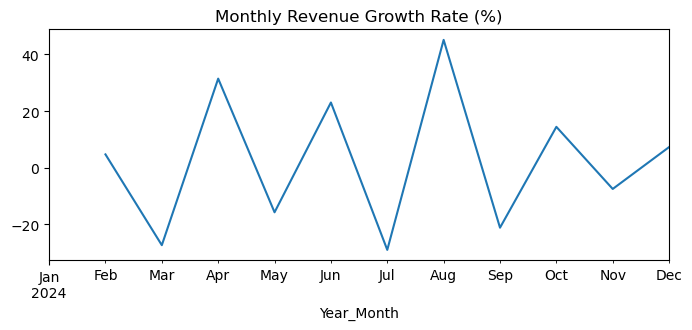

In [198]:
monthly_growth.plot(
    kind='line', 
    title='Monthly Revenue Growth Rate (%)', 
    figsize=(8,3))

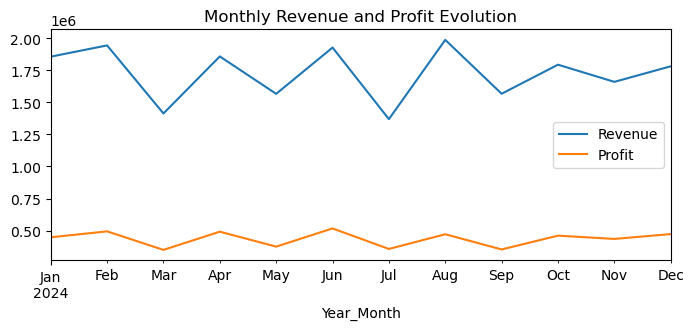

In [197]:
# Monthly profit aggregation
monthly_profit = df_financial.groupby('Year_Month')['Profit'].sum()

# Create combined Revenue and Profit visualization
monthly_revenue.plot(
    kind='line',
    figsize=(8,3),
    label='Revenue'
)

monthly_profit.plot(
    kind='line',
    figsize=(8,3),
    label='Profit'
)

plt.title('Monthly Revenue and Profit Evolution')
plt.legend()
plt.show()

In [186]:
Markdown(f"""
### 🧠 8.5 Time Series Insights

The time series analysis reveals a monthly revenue volatility of **{revenue_volatility}%**, indicating that **business performance fluctuates significantly over time**.

Although some months outperform others, the **revenue trend does not show a strong or consistent growth pattern**.

The best-performing month was **{best_month}**, generating **{best_month_revenue}**, while the weakest period was **{worst_month}**, with revenue of **{worst_month_revenue:.0f}$**.

These variations **may suggest the presence of seasonality effects, irregular demand patterns, or external business factors influencing sales performance**.

Further analysis would be required to **determine whether these fluctuations are structural or temporary**.
""")


### 🧠 8.5 Time Series Insights

The time series analysis reveals a monthly revenue volatility of **24.73%**, indicating that **business performance fluctuates significantly over time**.

Although some months outperform others, the **revenue trend does not show a strong or consistent growth pattern**.

The best-performing month was **2024-08**, generating **1986713.0**, while the weakest period was **2024-07**, with revenue of **1368905$**.

These variations **may suggest the presence of seasonality effects, irregular demand patterns, or external business factors influencing sales performance**.

Further analysis would be required to **determine whether these fluctuations are structural or temporary**.


In [206]:
Markdown(f"""
## 🧠 9 Final Conclusions

The analysis of the dataset provides a comprehensive view of the company's sales performance and key operational dynamics.

### 📊 Performance Overview
The business generates consistent revenue with a profit margin of **{profit_margin}%**, indicating a healthy level of profitability.

### 🏆 Product Strategy
Revenue is relatively well distributed across products, with the top-performing product contributing **{product_share.max()}%** of total revenue. This suggests a **low level of product dependency**.

### 🌍 Regional Distribution
Sales are moderately concentrated geographically, with the leading region accounting for **{region_share.max()}%** of revenue. This indicates some regional strength without excessive dependency.

### 👤 Sales Team Performance
Sales performance is **well balanced across the team**, with no single salesperson dominating revenue generation. This reduces operational risk and dependency on individuals.

### 🔁 Returns Impact
Returns represent only **{returns_impact}%** of total revenue, indicating that they have a **minimal impact on overall business performance**.

### 📈 Sales Trend
The analysis reveals a **highly volatile sales pattern**, with a monthly volatility of approximately **{revenue_volatility}%**.

Although there is a slight positive growth trend (**{revenue_volatility}%**), it is not strong or consistent, suggesting that performance is influenced by irregular factors rather than sustained growth.

### 📅 Opportunities
Lower-performing periods such as **July and March** may present opportunities for **targeted promotional strategies**. However, further data would be required to confirm whether these patterns are structural or temporary.

---

## 🚀 Key Takeaways

- The business is **profitable and diversified**
- There is **no strong dependency** on products, regions, or salespersons
- Sales performance is **unstable due to high volatility**
- Returns are **not a significant issue**
- There is **potential to optimize performance through better demand management**

---

## 📌 Next Steps

- Investigate drivers of sales volatility (seasonality, campaigns, external factors)
- Explore customer-level data to identify purchasing patterns
- Develop forecasting models to improve planning
- Implement targeted strategies for low-performing periods

""")


## 🧠 9 Final Conclusions

The analysis of the dataset provides a comprehensive view of the company's sales performance and key operational dynamics.

### 📊 Performance Overview
The business generates consistent revenue with a profit margin of **25.22%**, indicating a healthy level of profitability.

### 🏆 Product Strategy
Revenue is relatively well distributed across products, with the top-performing product contributing **14.14%** of total revenue. This suggests a **low level of product dependency**.

### 🌍 Regional Distribution
Sales are moderately concentrated geographically, with the leading region accounting for **27.02%** of revenue. This indicates some regional strength without excessive dependency.

### 👤 Sales Team Performance
Sales performance is **well balanced across the team**, with no single salesperson dominating revenue generation. This reduces operational risk and dependency on individuals.

### 🔁 Returns Impact
Returns represent only **0.07%** of total revenue, indicating that they have a **minimal impact on overall business performance**.

### 📈 Sales Trend
The analysis reveals a **highly volatile sales pattern**, with a monthly volatility of approximately **24.73%**.

Although there is a slight positive growth trend (**24.73%**), it is not strong or consistent, suggesting that performance is influenced by irregular factors rather than sustained growth.

### 📅 Opportunities
Lower-performing periods such as **July and March** may present opportunities for targeted promotional strategies. However, further data would be required to confirm whether these patterns are structural or temporary.

---

## 🚀 Key Takeaways

- The business is **profitable and diversified**
- There is **no strong dependency** on products, regions, or salespersons
- Sales performance is **unstable due to high volatility**
- Returns are **not a significant issue**
- There is **potential to optimize performance through better demand management**

---

## 📌 Next Steps

- Investigate drivers of sales volatility (seasonality, campaigns, external factors)
- Explore customer-level data to identify purchasing patterns
- Develop forecasting models to improve planning
- Implement targeted strategies for low-performing periods



## 💾 10 Export Clean Dataset

In [209]:
os.getcwd()

'/Users/dlf/Documents/PROJECT_BI_SALES_ANALYSIS/notebooks'

In [215]:
df_financial.to_csv('final_financial_EDA_sales.csv', 
    index=False,
    sep=';',
    decimal=',')